# Notebook 02 - Exploratory Data Analysis (EDA)
## Fake News Detection - NLP Assignment
### Person 2: W.A. Irusha Madushan (CIT-24-01-0514)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


In [4]:
# Load the cleaned dataset from Notebook 01
df = pd.read_csv('../data/cleaned_data.csv')

print("Dataset loaded successfully")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully
Shape: (72095, 5)


,title,text,content,processed_text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,law enforcement high alert following threat co...,1
1,NaN,Did they post their votes for Hillary already?,Did they post their votes for Hillary already?,post vote hillary already,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,unbelievable obamas attorney general say charl...,1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,"Bobby Jindal, raised Hindu, uses story of Chri...",bobby jindal raised hindu us story christian c...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",SATAN 2: Russia unvelis an image of its terrif...,satan russia unvelis image terrifying new supe...,1


## 1. Class Distribution
Visualizing the balance between Fake (1) and Real (0) news articles.

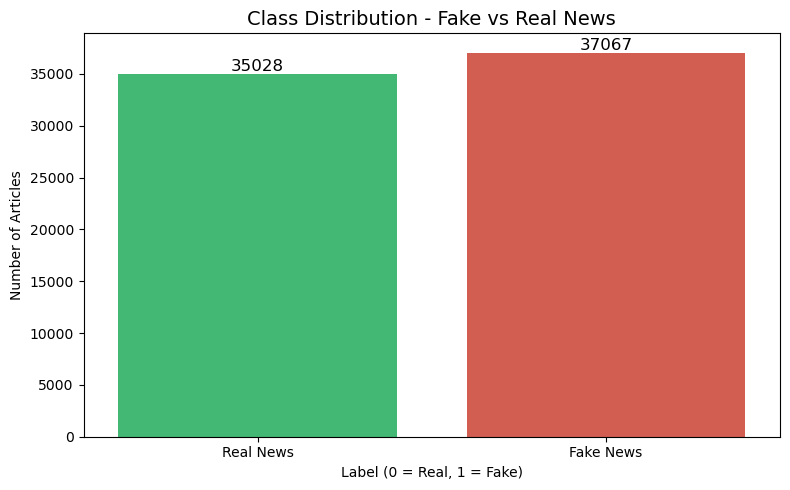

Real News: 35028
Fake News: 37067


In [5]:
# Class distribution
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='label', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Class Distribution - Fake vs Real News', fontsize=14)
plt.xlabel('Label (0 = Real, 1 = Fake)')
plt.ylabel('Number of Articles')
plt.xticks([0, 1], ['Real News', 'Fake News'])

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.savefig('../screenshots/class_distribution.png', dpi=150)
plt.show()
print("Real News:", df[df['label']==0].shape[0])
print("Fake News:", df[df['label']==1].shape[0])

### Insight
The dataset is well balanced with 35,028 real news articles (49%) 
and 37,067 fake news articles (51%). No class imbalance treatment needed.

## 2. Top 20 Most Frequent Words
Analyzing the most common words across all articles.

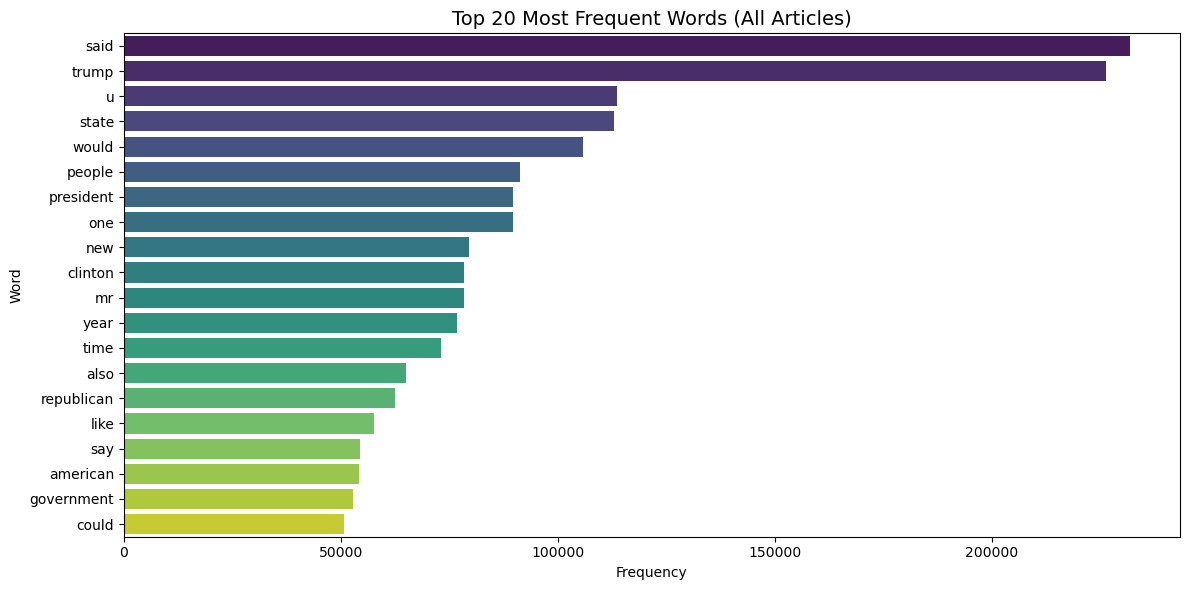

In [6]:
# Combine all processed text
all_words = ' '.join(df['processed_text'].dropna()).split()

# Counting word frequencies
word_freq = Counter(all_words)
top_20 = word_freq.most_common(20)

# Plot
words = [w[0] for w in top_20]
counts = [w[1] for w in top_20]

plt.figure(figsize=(12, 6))
sns.barplot(x=counts, y=words, palette='viridis')
plt.title('Top 20 Most Frequent Words (All Articles)', fontsize=14)
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.tight_layout()
plt.savefig('../screenshots/top20_words.png', dpi=150)
plt.show()

### Insight
Words like "said", "trump", "state" appear most frequently 
across all articles. These are common in both fake and real news, 
suggesting political content dominates the dataset.

## 3. Word Cloud - Fake News

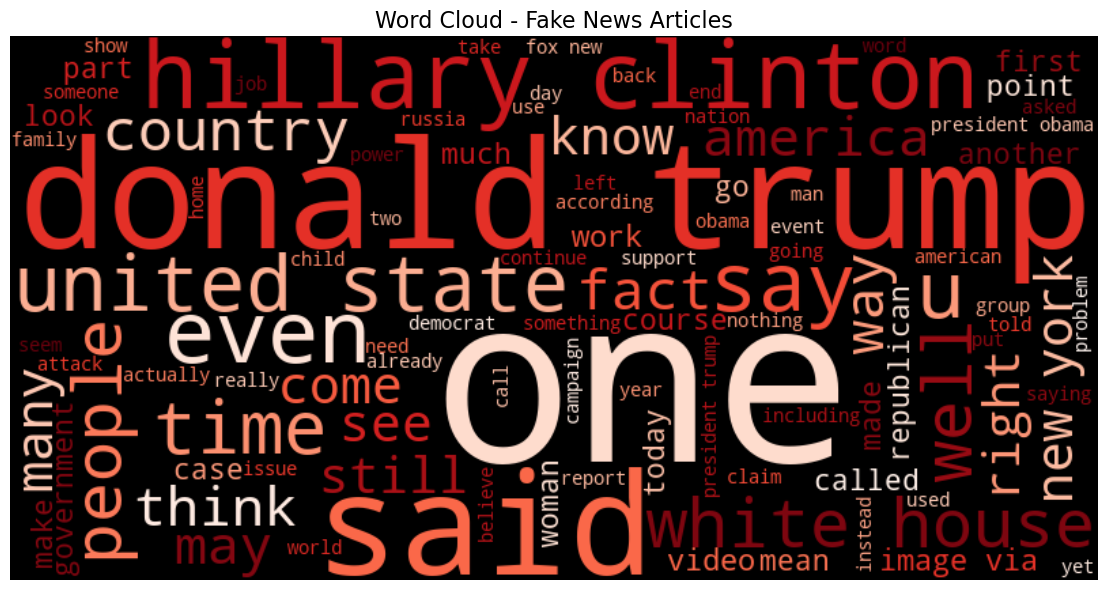

In [7]:
# Word cloud for fake news
fake_text = ' '.join(df[df['label']==1]['processed_text'].dropna())

wordcloud_fake = WordCloud(
    width=800, height=400,
    background_color='black',
    colormap='Reds',
    max_words=100
).generate(fake_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_fake, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Fake News Articles', fontsize=16)
plt.tight_layout()
plt.savefig('../screenshots/wordcloud_fake.png', dpi=150)
plt.show()

## 4. Word Cloud - Real News

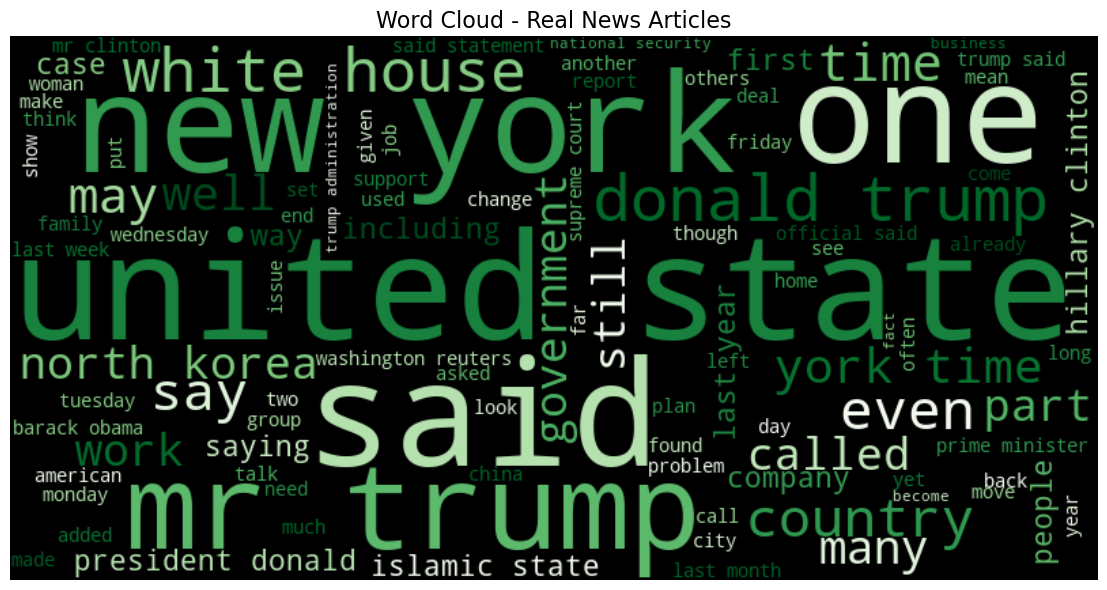

In [8]:
# Word cloud for real news
real_text = ' '.join(df[df['label']==0]['processed_text'].dropna())

wordcloud_real = WordCloud(
    width=800, height=400,
    background_color='black',
    colormap='Greens',
    max_words=100
).generate(real_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_real, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Real News Articles', fontsize=16)
plt.tight_layout()
plt.savefig('../screenshots/wordcloud_real.png', dpi=150)
plt.show()

### Insight
Fake news word cloud shows more emotionally charged and 
politically provocative words. Real news shows more formal, 
factual language with references to institutions and official sources.

## 5. Average Article Length Comparison

Average word count:
Real News (0): 336 words
Fake News (1): 286 words


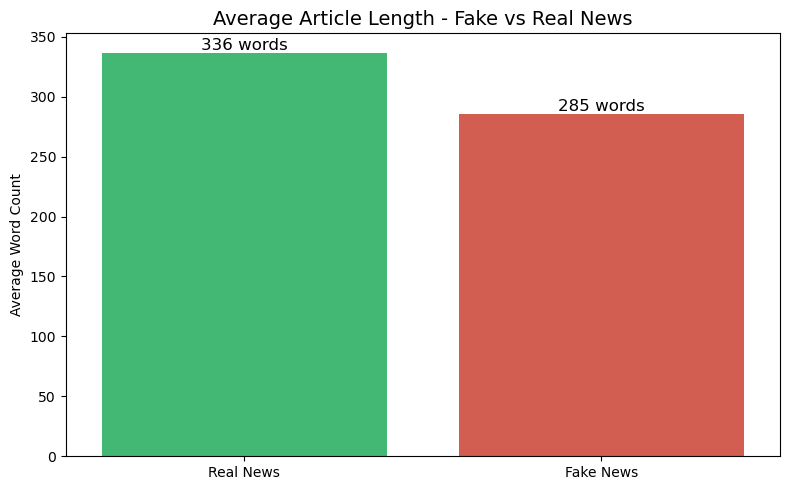

In [9]:
# Calculating article lengths
df['text_length'] = df['processed_text'].apply(lambda x: len(str(x).split()))

# Average length by class
avg_length = df.groupby('label')['text_length'].mean()
print("Average word count:")
print(f"Real News (0): {avg_length[0]:.0f} words")
print(f"Fake News (1): {avg_length[1]:.0f} words")

# Plot
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=['Real News', 'Fake News'], 
                 y=[avg_length[0], avg_length[1]], 
                 palette=['#2ecc71', '#e74c3c'])
plt.title('Average Article Length - Fake vs Real News', fontsize=14)
plt.ylabel('Average Word Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} words',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.savefig('../screenshots/article_length.png', dpi=150)
plt.show()

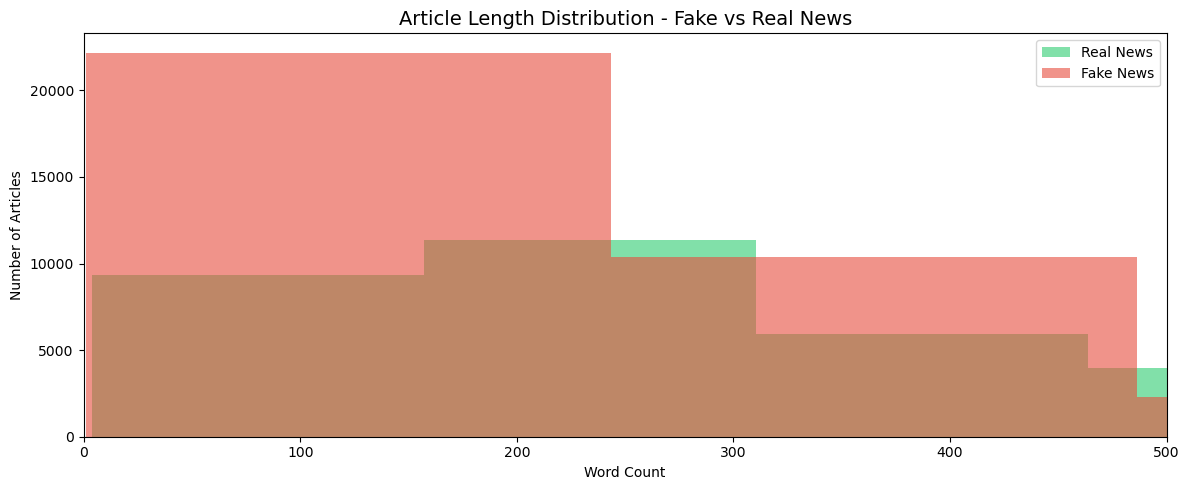

In [10]:
# Distribution of article lengths
plt.figure(figsize=(12, 5))
plt.hist(df[df['label']==0]['text_length'], bins=50, 
         alpha=0.6, color='#2ecc71', label='Real News')
plt.hist(df[df['label']==1]['text_length'], bins=50, 
         alpha=0.6, color='#e74c3c', label='Fake News')
plt.title('Article Length Distribution - Fake vs Real News', fontsize=14)
plt.xlabel('Word Count')
plt.ylabel('Number of Articles')
plt.legend()
plt.xlim(0, 500)
plt.tight_layout()
plt.savefig('../screenshots/length_distribution.png', dpi=150)
plt.show()

### Insight - Article Length
- Real news articles average 336 words while fake news articles 
  average 286 words
- Real news is on average 50 words longer than fake news
- This 15% difference in length suggests real news provides more 
  detailed, evidence-based reporting
- Fake news tends to be shorter and more direct, possibly to 
  quickly spread sensational claims without detailed evidence
- Article length can be a useful feature for our Random Forest 
  and CNN models to distinguish between fake and real news

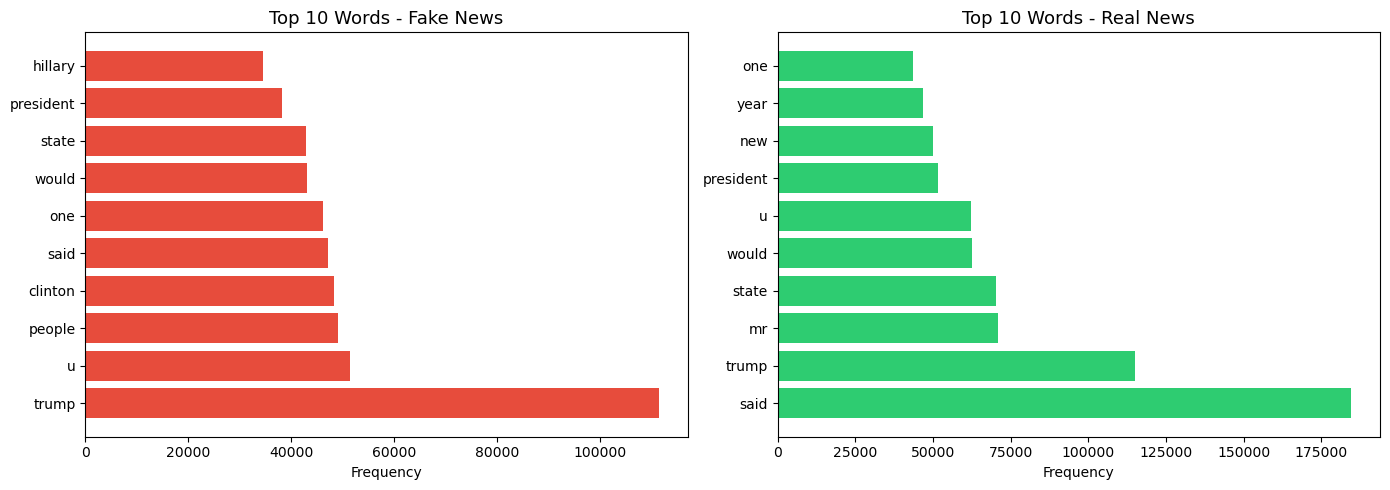

In [11]:
# Top 10 words in fake vs real news separately
fake_words = ' '.join(df[df['label']==1]['processed_text'].dropna()).split()
real_words = ' '.join(df[df['label']==0]['processed_text'].dropna()).split()

fake_top10 = Counter(fake_words).most_common(10)
real_top10 = Counter(real_words).most_common(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fake news top words
axes[0].barh([w[0] for w in fake_top10], 
             [w[1] for w in fake_top10], color='#e74c3c')
axes[0].set_title('Top 10 Words - Fake News', fontsize=13)
axes[0].set_xlabel('Frequency')

# Real news top words
axes[1].barh([w[0] for w in real_top10], 
             [w[1] for w in real_top10], color='#2ecc71')
axes[1].set_title('Top 10 Words - Real News', fontsize=13)
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('../screenshots/top10_fake_vs_real.png', dpi=150)
plt.show()

### Insight - Top Words Fake vs Real News

**Fake News:** The most frequent words are "trump", "u", "people" 
and "clinton". The word "u" stands out because it shows informal 
writing style which is not common in professional journalism. 
The focus on political names like Trump and Clinton shows that 
fake news in this dataset mostly targets political figures.

**Real News:** The most frequent words are "said", "trump", "mr" 
and "state". The word "said" appears most in real news because 
journalists quote sources directly. Words like "mr" and "state" 
show formal and professional writing style.

**What this means for our models:**
Both fake and real news mention Trump frequently, so our models 
cannot rely on names alone. However the writing style is clearly 
different — real news is more formal and source based while fake 
news is more informal and emotional. Random Forest and CNN should 
be able to pick up these word pattern differences during training.